# **Computer Vision Project: Facial Skin Ageing Classification**
# Menggunakan Model MobileNetv2

# 0.Import Library

In [70]:
import os
import shutil
import random
import pathlib
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from shutil import copyfile
from pathlib import Path
from tqdm import tqdm as tq

# Libraries untuk data preprocessing
import cv2
import skimage
from PIL import Image
from skimage import io, img_as_ubyte
from skimage.transform import resize, rotate, AffineTransform, warp
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

# Libraries untuk modeling
import keras
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img 
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

# 1.Loading Dataset

In [5]:
# Download latest version
path = kagglehub.dataset_download("siddheshbhatt/facial-skin-ageing", output_dir=r"./dataset")

print("Path to dataset files:", path)

100%|██████████| 239M/239M [00:19<00:00, 12.7MB/s] 

Extracting files...


Path to dataset files: ./dataset


# 2.Data Preprocessing

In [6]:
# Membuat kamus yang menyimpan gambar untuk setiap kelas dalam data
lung_img = {}

path = 'dataset'
path_sub = os.path.join(path, 'skin_ageing_symptoms')
os.listdir(path_sub)

['acne', 'clear_face', 'darkspots', 'puffy_eyes', 'wrinkles']

In [7]:
for i in os.listdir(path_sub):
    lung_img[i] = os.listdir(os.path.join(path_sub, i))

lung_img

{'acne': ['1.png',
  '102.png',
  '108.png',
  '109.png',
  '110.png',
  '113.png',
  '115.png',
  '116.png',
  '12.png',
  '120.png',
  '123.png',
  '124.png',
  '131.png',
  '135.png',
  '136.png',
  '137.png',
  '138.png',
  '146.png',
  '147.png',
  '152.png',
  '154.png',
  '156.png',
  '158.png',
  '16.png',
  '165.png',
  '17.png',
  '170.png',
  '174.png',
  '176.png',
  '178.png',
  '179.png',
  '18.png',
  '183.png',
  '188.png',
  '189.png',
  '190.png',
  '193.png',
  '194.png',
  '2.png',
  '203.png',
  '204.png',
  '205.png',
  '208.png',
  '21.png',
  '211.png',
  '212.png',
  '215.png',
  '22.png',
  '225.png',
  '227.png',
  '3.png',
  '4.png',
  '43.png',
  '46.png',
  '49.png',
  '5.png',
  '50.png',
  '52.png',
  '54.png',
  '60.png',
  '63.png',
  '66.png',
  '73.png',
  '75.png',
  '80.png',
  '81.png',
  '83.png',
  '86.png',
  '87.png',
  '89.png',
  '9.png',
  '92.png',
  '93.png',
  '98.png',
  '99.png',
  'dark_0_levle0_58.png',
  'dark_10_levle3_94.png',
  '

In [8]:
class_name = lung_img.keys()
n_class = len(lung_img.keys())

print(f'Jumlah Kelas: {n_class}')
print(f'Nama Kelas: {class_name}')

Jumlah Kelas: 5
Nama Kelas: dict_keys(['acne', 'clear_face', 'darkspots', 'puffy_eyes', 'wrinkles'])


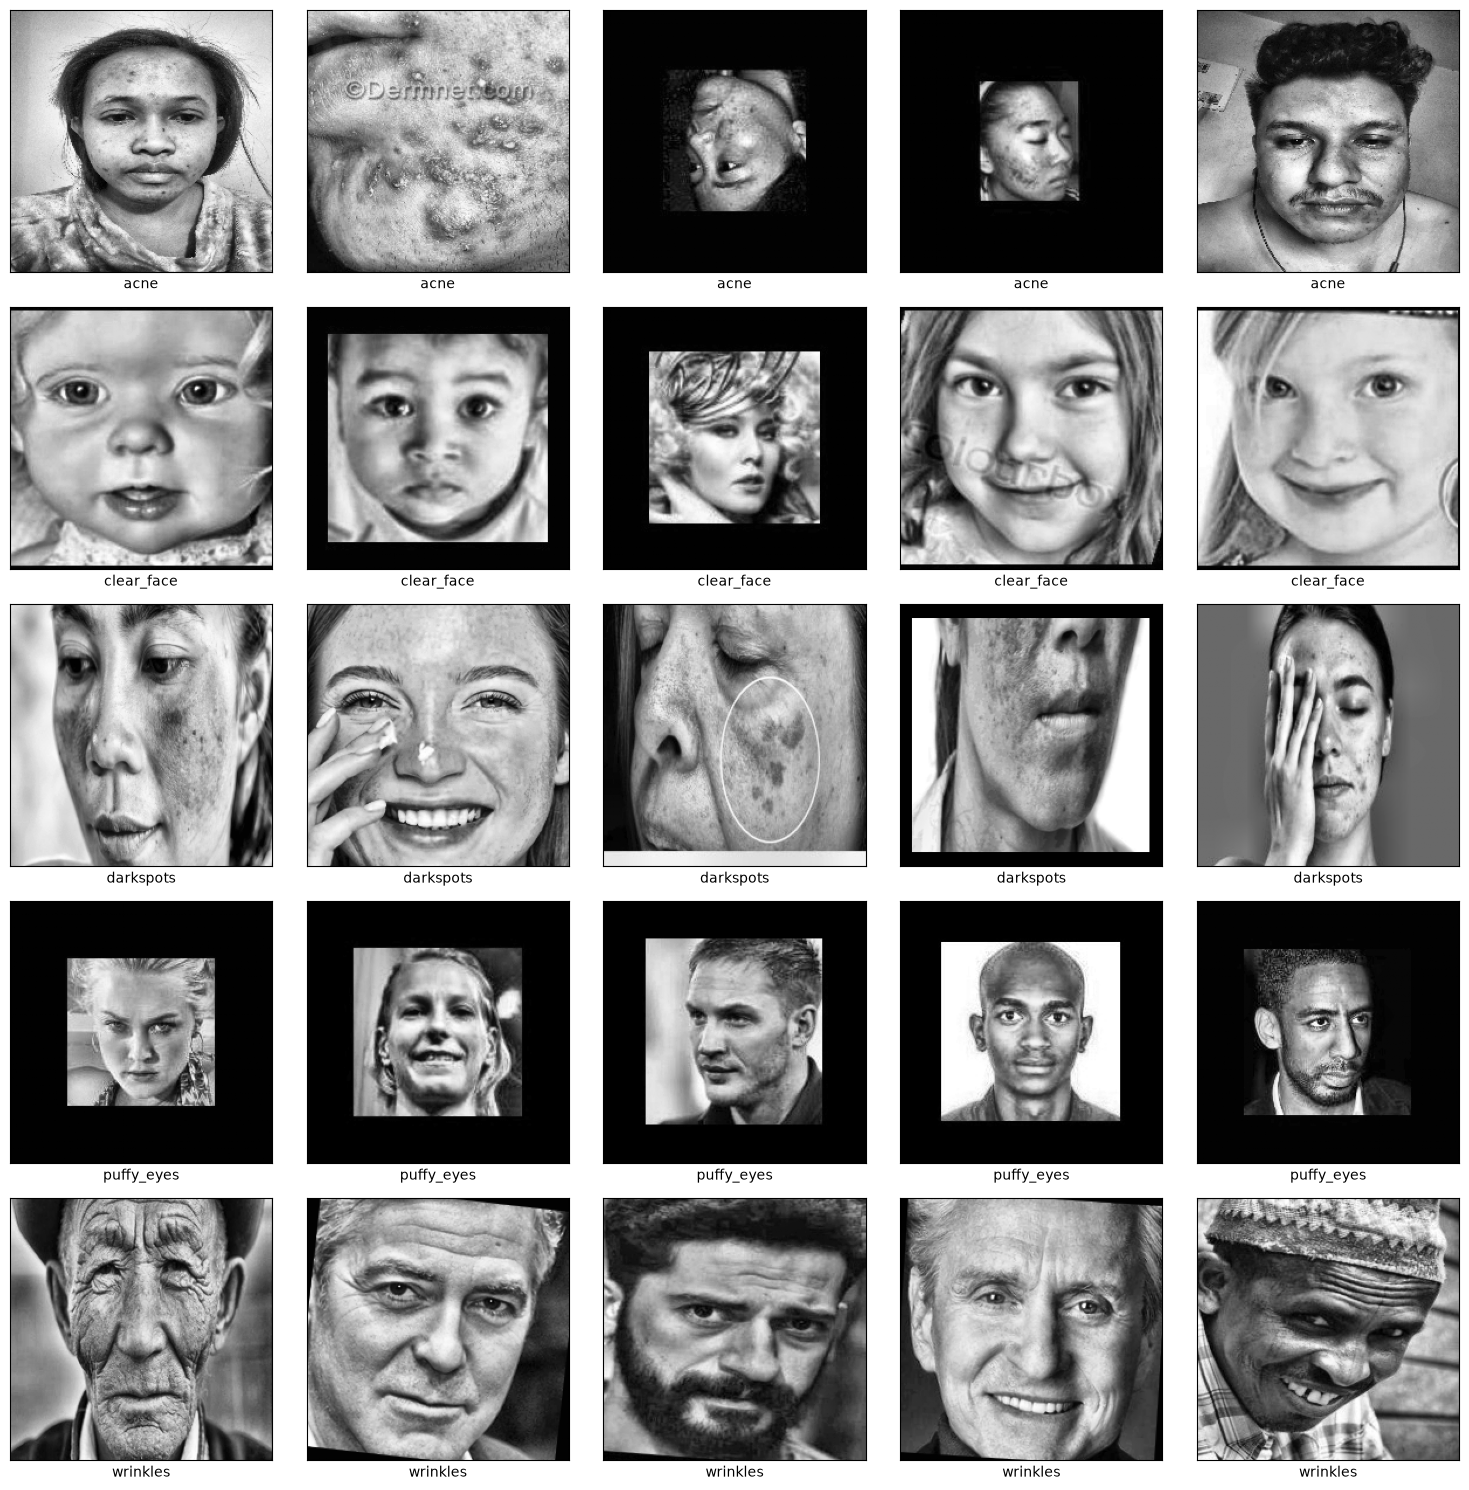

In [9]:
# Menampilkan 5 gambar secara masing-masing kelas yang ada dalam data
fig, ax = plt.subplots(n_class, 5, figsize=(15, 15))

for i, cls in enumerate(os.listdir(path_sub)):
    images = np.random.choice(lung_img[cls], 5, replace=False)

    for j, img in enumerate(images):
        img_path = os.path.join(path_sub, cls, img)
        im = Image.open(img_path).convert("L")
        ax[i, j].imshow(im, cmap='gray')
        ax[i, j].set(xlabel=cls, xticks=[], yticks=[])

fig.tight_layout()

In [10]:
lung_path = 'dataset/skin_ageing_symptoms'

file_name = []
labels = []
full_path = []

data = [
    (name, os.path.basename(path), os.path.join(path, name))
    for path, subdirs, files in os.walk(lung_path)
    for name in files
]

In [11]:
data

[('1.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\1.png'),
 ('102.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\102.png'),
 ('108.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\108.png'),
 ('109.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\109.png'),
 ('110.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\110.png'),
 ('113.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\113.png'),
 ('115.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\115.png'),
 ('116.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\116.png'),
 ('12.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\12.png'),
 ('120.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\120.png'),
 ('123.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\123.png'),
 ('124.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\124.png'),
 ('131.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\131.png'),
 ('135.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\135.png'),
 ('136.png', 'acne', 'dataset/skin_agein

In [12]:
file_name = [x[0] for x in data]
file_name

['1.png',
 '102.png',
 '108.png',
 '109.png',
 '110.png',
 '113.png',
 '115.png',
 '116.png',
 '12.png',
 '120.png',
 '123.png',
 '124.png',
 '131.png',
 '135.png',
 '136.png',
 '137.png',
 '138.png',
 '146.png',
 '147.png',
 '152.png',
 '154.png',
 '156.png',
 '158.png',
 '16.png',
 '165.png',
 '17.png',
 '170.png',
 '174.png',
 '176.png',
 '178.png',
 '179.png',
 '18.png',
 '183.png',
 '188.png',
 '189.png',
 '190.png',
 '193.png',
 '194.png',
 '2.png',
 '203.png',
 '204.png',
 '205.png',
 '208.png',
 '21.png',
 '211.png',
 '212.png',
 '215.png',
 '22.png',
 '225.png',
 '227.png',
 '3.png',
 '4.png',
 '43.png',
 '46.png',
 '49.png',
 '5.png',
 '50.png',
 '52.png',
 '54.png',
 '60.png',
 '63.png',
 '66.png',
 '73.png',
 '75.png',
 '80.png',
 '81.png',
 '83.png',
 '86.png',
 '87.png',
 '89.png',
 '9.png',
 '92.png',
 '93.png',
 '98.png',
 '99.png',
 'dark_0_levle0_58.png',
 'dark_10_levle3_94.png',
 'dark_11_acne3 (004).png',
 'dark_12_levle0_58.png',
 'dark_13_levle0_59.png',
 'dark_1

In [13]:
labels = [x[1] for x in data]
labels

['acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 

In [14]:
full_path = [x[2] for x in data]
full_path

['dataset/skin_ageing_symptoms\\acne\\1.png',
 'dataset/skin_ageing_symptoms\\acne\\102.png',
 'dataset/skin_ageing_symptoms\\acne\\108.png',
 'dataset/skin_ageing_symptoms\\acne\\109.png',
 'dataset/skin_ageing_symptoms\\acne\\110.png',
 'dataset/skin_ageing_symptoms\\acne\\113.png',
 'dataset/skin_ageing_symptoms\\acne\\115.png',
 'dataset/skin_ageing_symptoms\\acne\\116.png',
 'dataset/skin_ageing_symptoms\\acne\\12.png',
 'dataset/skin_ageing_symptoms\\acne\\120.png',
 'dataset/skin_ageing_symptoms\\acne\\123.png',
 'dataset/skin_ageing_symptoms\\acne\\124.png',
 'dataset/skin_ageing_symptoms\\acne\\131.png',
 'dataset/skin_ageing_symptoms\\acne\\135.png',
 'dataset/skin_ageing_symptoms\\acne\\136.png',
 'dataset/skin_ageing_symptoms\\acne\\137.png',
 'dataset/skin_ageing_symptoms\\acne\\138.png',
 'dataset/skin_ageing_symptoms\\acne\\146.png',
 'dataset/skin_ageing_symptoms\\acne\\147.png',
 'dataset/skin_ageing_symptoms\\acne\\152.png',
 'dataset/skin_ageing_symptoms\\acne\\154.p

In [15]:
df = pd.DataFrame({
    'file_name': file_name,
    'label': labels,
    'path': full_path
})

In [16]:
df.head(-10)

,file_name,label,path
0,1.png,acne,dataset/skin_ageing_symptoms\acne\1.png
1,102.png,acne,dataset/skin_ageing_symptoms\acne\102.png
2,108.png,acne,dataset/skin_ageing_symptoms\acne\108.png
3,109.png,acne,dataset/skin_ageing_symptoms\acne\109.png
4,110.png,acne,dataset/skin_ageing_symptoms\acne\110.png
...,...,...,...
3245,skinv2_wrinkles_light_01651.png,wrinkles,dataset/skin_ageing_symptoms\wrinkles\skinv2_w...
3246,skinv2_wrinkles_light_01657.png,wrinkles,dataset/skin_ageing_symptoms\wrinkles\skinv2_w...
3247,skinv2_wrinkles_light_01662.png,wrinkles,dataset/skin_ageing_symptoms\wrinkles\skinv2_w...
3248,skinv2_wrinkles_light_01665.png,wrinkles,dataset/skin_ageing_symptoms\wrinkles\skinv2_w...


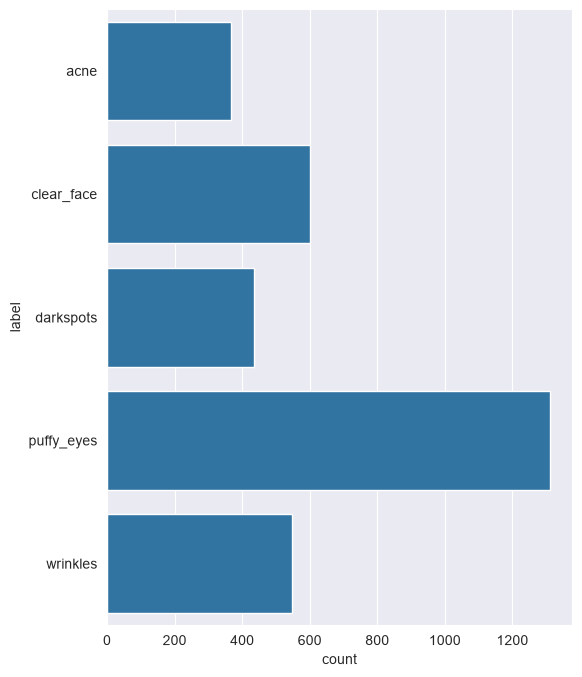

In [17]:
# Visualisasi distribusi kelas
Label = df['label']
plt.figure(figsize=(6, 8))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

In [18]:
count_label = df["label"].value_counts()
print(count_label)

label
puffy_eyes    1311
clear_face     600
wrinkles       548
darkspots      434
acne           367
Name: count, dtype: int64


In [19]:
class imageAugmentation:
    def __init__(self, img) -> None:
        self.img = img
        self.image = cv2.cvtColor(self.img, 0)
        self.image = cv2.resize(self.img, (244, 244))

    def anticlockwise_rotation(self):
        sudut = random.randint(0, 180)
        return rotate(self.image, sudut)

    def clockwise_rotation(self):
        sudut = random.randint(0,180)
        return rotate(self.image, -sudut)

    def flip_up_down(self):
        return np.flipud(self.image)

    def add_brightness(self):
        return adjust_gamma(self.image, gamma=0.5, gain=1)

    def blur_image(self):
        return cv2.GaussianBlur(self.image, (9, 9), 0)

    def sheared(self):
        transform = AffineTransform(shear=0.2)
        return warp(self.image, transform, mode='wrap')

    def warp_shift(self):
        transform = AffineTransform(translation=(0, 40))
        return warp(self.image, transform, mode='wrap')

In [20]:
transformations = {
    "rotate anticlockwise": lambda img: imageAugmentation(img).anticlockwise_rotation(),
    "rotate clockwise": lambda img: imageAugmentation(img).clockwise_rotation(),
    "warp_shift": lambda img: imageAugmentation(img).warp_shift(),
    "blurring image": lambda img: imageAugmentation(img).blur_image(),
    "add brightness": lambda img: imageAugmentation(img).add_brightness(),
    "flip up down": lambda img: imageAugmentation(img).flip_up_down(),
    "shear image": lambda img: imageAugmentation(img).sheared(),
}

In [21]:
def read_img(images_path):
    return [os.path.join(images_path, im) for im in os.listdir(images_path)]

In [22]:
def runAugmentation(transformations, images, images_path, generate_img):
    i = 1
    image_to_generate = generate_img
    while i <= image_to_generate:
        image = random.choice(images)
        try:
            original_img = io.imread(image)
            transformed_img = None
            n = 0  # Variabel untuk melakukan iterasi sampai jumlah transformasi yang akan diterapkan
            transformations_count = random.randint(1, len(transformations))

            while n <= transformations_count:
                key = random.choice(list(transformations))
                transformed_img = transformations[key](original_img)
                n = n + 1

            new_image_path = '%s/augmented_image_%s.jpg' % (images_path, i)
            # Mengonversi gambar ke format byte yang tidak ditandatangani, dengan nilai dalam [0, 255]
            transformed_img = img_as_ubyte(transformed_img)
            # Simpan hasil transformasi augmentasi pada gambar
            cv2.imwrite(new_image_path, transformed_img)
            i += 1
        except ValueError as e:
            print('could not read the',image ,':',e,'hence skipping it.')

In [23]:
# Augmentasi data acne
acne_path = os.path.join(lung_path, 'acne')
acne_img = read_img(acne_path)
acne_img

['dataset/skin_ageing_symptoms\\acne\\1.png',
 'dataset/skin_ageing_symptoms\\acne\\102.png',
 'dataset/skin_ageing_symptoms\\acne\\108.png',
 'dataset/skin_ageing_symptoms\\acne\\109.png',
 'dataset/skin_ageing_symptoms\\acne\\110.png',
 'dataset/skin_ageing_symptoms\\acne\\113.png',
 'dataset/skin_ageing_symptoms\\acne\\115.png',
 'dataset/skin_ageing_symptoms\\acne\\116.png',
 'dataset/skin_ageing_symptoms\\acne\\12.png',
 'dataset/skin_ageing_symptoms\\acne\\120.png',
 'dataset/skin_ageing_symptoms\\acne\\123.png',
 'dataset/skin_ageing_symptoms\\acne\\124.png',
 'dataset/skin_ageing_symptoms\\acne\\131.png',
 'dataset/skin_ageing_symptoms\\acne\\135.png',
 'dataset/skin_ageing_symptoms\\acne\\136.png',
 'dataset/skin_ageing_symptoms\\acne\\137.png',
 'dataset/skin_ageing_symptoms\\acne\\138.png',
 'dataset/skin_ageing_symptoms\\acne\\146.png',
 'dataset/skin_ageing_symptoms\\acne\\147.png',
 'dataset/skin_ageing_symptoms\\acne\\152.png',
 'dataset/skin_ageing_symptoms\\acne\\154.p

In [24]:
print(f"Jumlah gambar original: {len(acne_img)}")

Jumlah gambar original: 367


In [25]:
runAugmentation(transformations, acne_img, acne_path, 4000)

In [26]:
# Augmentasi data clear face
clear_face_path = os.path.join(lung_path, 'clear_face')
clear_face_img = read_img(clear_face_path)
clear_face_img

['dataset/skin_ageing_symptoms\\clear_face\\10_0_0_20170110215927291.jpg.chip.png',
 'dataset/skin_ageing_symptoms\\clear_face\\10_0_0_20170110220235233.jpg.chip.png',
 'dataset/skin_ageing_symptoms\\clear_face\\10_0_0_20170110220541850.jpg.chip.png',
 'dataset/skin_ageing_symptoms\\clear_face\\10_0_0_20170110221714752.jpg.chip.png',
 'dataset/skin_ageing_symptoms\\clear_face\\10_0_0_20170110221811823.jpg.chip.png',
 'dataset/skin_ageing_symptoms\\clear_face\\10_0_0_20170110225417177.jpg.chip.png',
 'dataset/skin_ageing_symptoms\\clear_face\\10_0_0_20170116201328751.jpg.chip.png',
 'dataset/skin_ageing_symptoms\\clear_face\\10_0_0_20170117135444407.jpg.chip.png',
 'dataset/skin_ageing_symptoms\\clear_face\\10_0_0_20170120220628194.jpg.chip.png',
 'dataset/skin_ageing_symptoms\\clear_face\\10_0_1_20170110220523360.jpg.chip.png',
 'dataset/skin_ageing_symptoms\\clear_face\\10_0_1_20170110223455893.jpg.chip.png',
 'dataset/skin_ageing_symptoms\\clear_face\\10_0_1_20170110223848885.jpg.chi

In [27]:
print(f"Jumlah gambar original: {len(clear_face_img)}")

Jumlah gambar original: 600


In [28]:
runAugmentation(transformations, clear_face_img, clear_face_path, 4000)

In [29]:
# Augmentasi data darkspots
darkspots_path = os.path.join(lung_path, 'darkspots')
darkspots_img = read_img(darkspots_path)
darkspots_img

['dataset/skin_ageing_symptoms\\darkspots\\0033_aug_1.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0033_aug_2.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0079_aug_1.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0079_aug_2.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0079_aug_3.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0085_aug_1.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0085_aug_2.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0090_aug_2.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0090_aug_3.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0090_aug_4.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0102.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0104_aug_1.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0104_aug_4.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0107_aug_1.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0107_aug_4.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0123_aug_2.png',
 'dataset/skin_ageing_symptoms\\darkspots\\012

In [30]:
print(f"Jumlah gambar original: {len(darkspots_img)}")

Jumlah gambar original: 434


In [31]:
runAugmentation(transformations, darkspots_img, darkspots_path, 4000)

In [32]:
# Augmentasi data wrinkles 
wrinkles_path = os.path.join(lung_path, 'wrinkles')
wrinkles_img = read_img(wrinkles_path)
wrinkles_img

['dataset/skin_ageing_symptoms\\wrinkles\\0013_aug_4.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0014.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0014_aug_2.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0014_aug_4.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0017_aug_1.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0017_aug_4.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0018_aug_3.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0020.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0020_aug_2.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0020_aug_3.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0020_aug_4.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0021.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0021_aug_2.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0021_aug_3.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0034.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0034_aug_2.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0034_aug_3.png',
 'dataset/skin_ageing

In [33]:
print(f"Jumlah gambar original: {len(wrinkles_img)}")

Jumlah gambar original: 548


In [34]:
runAugmentation(transformations, wrinkles_img, wrinkles_path, 4000)

In [35]:
# Augmentasi data puffy eyes
puffy_eyes_path = os.path.join(lung_path, 'puffy_eyes')
puffy_eyes_img = read_img(puffy_eyes_path)
puffy_eyes_img

['dataset/skin_ageing_symptoms\\puffy_eyes\\0002_aug_4.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0003.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0003_aug_3.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0004_aug_3.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0004_aug_4.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0005.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0005_aug_1.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0005_aug_2.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0005_aug_3.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0005_aug_4.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0008.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0008_aug_1.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0025_aug_1.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0042_aug_1.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0048.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0048_aug_1.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0048

In [36]:
print(f"Jumlah gambar original: {len(puffy_eyes_img)}")

Jumlah gambar original: 1311


In [37]:
runAugmentation(transformations, puffy_eyes_img, puffy_eyes_path, 2500)

In [38]:
for path, subdirs, files in os.walk(lung_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split("\\")[-1])
        file_name.append(name)

df_augmented = pd.DataFrame(
    {"path": full_path, "file_name": file_name, "label": labels}
)

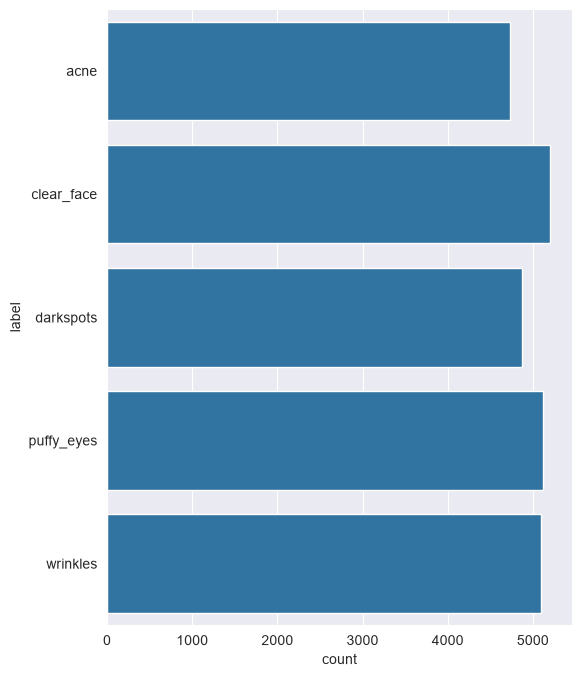

In [39]:
# Visualisasi distribusi kelas
Label = df_augmented["label"]
plt.figure(figsize=(6, 8))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

In [40]:
df_augmented.groupby(["label"]).size()

label
acne          4734
clear_face    5200
darkspots     4868
puffy_eyes    5122
wrinkles      5096
dtype: int64

In [41]:
df_augmented.head(-10)

,path,file_name,label
0,dataset/skin_ageing_symptoms\acne\1.png,1.png,acne
1,dataset/skin_ageing_symptoms\acne\102.png,102.png,acne
2,dataset/skin_ageing_symptoms\acne\108.png,108.png,acne
3,dataset/skin_ageing_symptoms\acne\109.png,109.png,acne
4,dataset/skin_ageing_symptoms\acne\110.png,110.png,acne
...,...,...,...
25005,dataset/skin_ageing_symptoms\wrinkles\skinv2_w...,skinv2_wrinkles_light_01651.png,wrinkles
25006,dataset/skin_ageing_symptoms\wrinkles\skinv2_w...,skinv2_wrinkles_light_01657.png,wrinkles
25007,dataset/skin_ageing_symptoms\wrinkles\skinv2_w...,skinv2_wrinkles_light_01662.png,wrinkles
25008,dataset/skin_ageing_symptoms\wrinkles\skinv2_w...,skinv2_wrinkles_light_01665.png,wrinkles


In [42]:
df_augmented = df_augmented.sample(frac=1).reset_index(drop=True)

In [43]:
df_augmented.head()

,path,file_name,label
0,dataset/skin_ageing_symptoms\darkspots\augment...,augmented_image_669.jpg,darkspots
1,dataset/skin_ageing_symptoms\acne\augmented_im...,augmented_image_2726.jpg,acne
2,dataset/skin_ageing_symptoms\clear_face\augmen...,augmented_image_2627.jpg,clear_face
3,dataset/skin_ageing_symptoms\clear_face\augmen...,augmented_image_3897.jpg,clear_face
4,dataset/skin_ageing_symptoms\darkspots\augment...,augmented_image_1056.jpg,darkspots


In [44]:
print('Total dataset yang digunakan:', len(df_augmented))

Total dataset yang digunakan: 25020


# 3.Splitting Data

In [45]:
X = df_augmented['path']
y = df_augmented['label']

In [46]:
X

0        dataset/skin_ageing_symptoms\darkspots\augment...
1        dataset/skin_ageing_symptoms\acne\augmented_im...
2        dataset/skin_ageing_symptoms\clear_face\augmen...
3        dataset/skin_ageing_symptoms\clear_face\augmen...
4        dataset/skin_ageing_symptoms\darkspots\augment...
                               ...                        
25015    dataset/skin_ageing_symptoms\wrinkles\augmente...
25016    dataset/skin_ageing_symptoms\puffy_eyes\celeba...
25017    dataset/skin_ageing_symptoms\wrinkles\augmente...
25018    dataset/skin_ageing_symptoms\puffy_eyes\augmen...
25019    dataset/skin_ageing_symptoms\clear_face\augmen...
Name: path, Length: 25020, dtype: str

In [47]:
y

0         darkspots
1              acne
2        clear_face
3        clear_face
4         darkspots
            ...    
25015      wrinkles
25016    puffy_eyes
25017      wrinkles
25018    puffy_eyes
25019    clear_face
Name: label, Length: 25020, dtype: str

In [48]:
train_size = int(len(df_augmented) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [49]:
df_tr = pd.DataFrame({'path': X_train, 'label': y_train, 'set': 'train'})
df_te = pd.DataFrame({'path': X_test, 'label': y_test, 'set': 'test'})
df_all = pd.concat([df_tr, df_te], ignore_index=True)

In [50]:
print(df_all.groupby(['label', 'set']).size())

label       set  
acne        test      941
            train    3793
clear_face  test     1031
            train    4169
darkspots   test      935
            train    3933
puffy_eyes  test     1069
            train    4053
wrinkles    test     1028
            train    4068
dtype: int64


In [51]:
df_all.head(-10)

,path,label,set
0,dataset/skin_ageing_symptoms\darkspots\augment...,darkspots,train
1,dataset/skin_ageing_symptoms\acne\augmented_im...,acne,train
2,dataset/skin_ageing_symptoms\clear_face\augmen...,clear_face,train
3,dataset/skin_ageing_symptoms\clear_face\augmen...,clear_face,train
4,dataset/skin_ageing_symptoms\darkspots\augment...,darkspots,train
...,...,...,...
25005,dataset/skin_ageing_symptoms\darkspots\skinv2_...,darkspots,test
25006,dataset/skin_ageing_symptoms\clear_face\augmen...,clear_face,test
25007,dataset/skin_ageing_symptoms\acne\augmented_im...,acne,test
25008,dataset/skin_ageing_symptoms\clear_face\augmen...,clear_face,test


In [52]:
dataset_path = './dataset-final'
# Buat direktori train dan test
for index, row in tq(df_all.iterrows()):
    # Deteksi filepath
    file_path = row['path']
    if os.path.exists(file_path) == False:
        file_path = os.path.join(
            lung_path, row['label'], row['image'].split('.')[0]
        )

    # Buat direktori tujuan folder
    if os.path.exists(os.path.join(dataset_path, row['set'], row['label'])) == False:
        os.makedirs(os.path.join(dataset_path, row['set'], row['label']))

    # Tentukan tujuan file
    destination_file_name = os.path.basename(file_path)
    file_dest = os.path.join(
        dataset_path, row['set'], row['label'], destination_file_name
    )

    # Salin file dari sumber ke tujuan
    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path, file_dest)

25020it [00:35, 713.06it/s] 


In [53]:
TRAIN_DIR = './dataset-final/train'
TEST_DIR = './dataset-final/test'

train_acne = os.path.join(TRAIN_DIR, 'acne')
train_clear_face = os.path.join(TRAIN_DIR, 'clear_face')
train_darkspots = os.path.join(TRAIN_DIR, "darkspots")
train_puffy_eyes = os.path.join(TRAIN_DIR, 'puffy_eyes')
train_wrinkles = os.path.join(TRAIN_DIR, 'wrinkles')

In [54]:
print("Total number of acne images in training set: ", len(os.listdir(train_acne)))
print("Total number of clear face images in training set: ",len(os.listdir(train_clear_face)))
print("Total number of darkspots images in training set: ",len(os.listdir(train_darkspots)))
print("Total number of puffy eyes images in training set: ",len(os.listdir(train_puffy_eyes)))
print("Total number of wrinkles images in training set: ",len(os.listdir(train_wrinkles)))

Total number of acne images in training set:  3562
Total number of clear face images in training set:  3765
Total number of darkspots images in training set:  3651
Total number of puffy eyes images in training set:  3241
Total number of wrinkles images in training set:  3713


In [55]:
test_acne = os.path.join(TEST_DIR, 'acne')
test_clear_face = os.path.join(TEST_DIR, 'clear_face')
test_darkspots = os.path.join(TEST_DIR, 'darkspots')
test_puffy_eyes = os.path.join(TEST_DIR, 'puffy_eyes')
test_wrinkles = os.path.join(TEST_DIR, 'wrinkles')

In [56]:
print("Total number of acne images in testing set: ", len(os.listdir(test_acne)))
print("Total number of clear face images in testing set: ",len(os.listdir(test_clear_face)))
print("Total number of darkspots images in testing set: ",len(os.listdir(test_darkspots)))
print("Total number of puffy eyes images in testing set: ",len(os.listdir(test_puffy_eyes)))
print("Total number of wrinkles images in testing set: ",len(os.listdir(test_wrinkles)))

Total number of acne images in testing set:  923
Total number of clear face images in testing set:  1001
Total number of darkspots images in testing set:  917
Total number of puffy eyes images in testing set:  994
Total number of wrinkles images in testing set:  1009


# 4.Modeling

In [57]:
datagen = ImageDataGenerator(rescale=1/255.0, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1/255.0)

In [58]:
datagen

In [59]:
test_datagen

In [60]:
train_generator = datagen.flow_from_directory(
    TRAIN_DIR,
    batch_size=32,
    target_size=(150, 150),
    color_mode='rgb',
    class_mode='sparse',
    subset='training',
    shuffle=True,
)

validation_generator = datagen.flow_from_directory(
    TRAIN_DIR,
    batch_size=32,
    target_size=(150, 150),
    color_mode='rgb',
    class_mode='sparse',
    subset='validation',
    shuffle=False,
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    batch_size=1,
    target_size=(150, 150),
    color_mode='rgb',
    class_mode='sparse',
    shuffle=False,
)

Found 14347 images belonging to 5 classes.
Found 3585 images belonging to 5 classes.
Found 4844 images belonging to 5 classes.


In [61]:
model_CNN = Sequential();

# Layer 1
model_CNN.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(150, 150, 3)))
model_CNN.add(BatchNormalization())
model_CNN.add(MaxPool2D(2, 2))

# Layer 2
model_CNN.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model_CNN.add(BatchNormalization())
model_CNN.add(MaxPool2D(2, 2))

# Layer 3
model_CNN.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model_CNN.add(BatchNormalization())
model_CNN.add(MaxPool2D(2, 2))

# Layer 4
model_CNN.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model_CNN.add(BatchNormalization())
model_CNN.add(MaxPool2D(2, 2))

# Flatten layer
model_CNN.add(Flatten())

# # 1nd Dense Layer
model_CNN.add(Dense(128, activation="relu"))

# 1nd Dropout Layer
model_CNN.add(Dropout(0.5))

# 2nd Dense Layer
model_CNN.add(Dense(64, activation="relu"))

# 2nd Dropout Layer
model_CNN.add(Dropout(0.3))

# # Final Dense layer 
model_CNN.add(Dense(5, activation="softmax"))

d:\Machine Learning\Belajar_Fundamental_Deep_Learning\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
model_CNN.compile(
    optimizer=Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [63]:
model_CNN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,327,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,578,053 (6.02 MB)

 Trainable params: 1,577,349 (6.02 MB)

 Non-trainable params: 704 (2.75 KB)

In [64]:
# Hitung jumlah data tiap kelas
count_acne = len(os.listdir(train_acne))
count_clear_face = len(os.listdir(train_clear_face))
count_darkspots = len(os.listdir(train_darkspots))
count_puffy_eyes = len(os.listdir(train_puffy_eyes))
count_wrinkles = len(os.listdir(train_wrinkles))

total = (
    count_acne + count_clear_face + count_darkspots + count_puffy_eyes + count_wrinkles
)
n_classes = 5

weight_0 = (1 / count_acne) * (total) / n_classes
weight_1 = (1 / count_clear_face) * (total) / n_classes
weight_2 = (1 / count_darkspots) * (total) / n_classes
weight_3 = (1 / count_puffy_eyes) * (total) / n_classes
weight_4 = (1 / count_wrinkles) * (total) / n_classes

class_weights = {
    0: weight_0,  # acne
    1: weight_1,  # clear_face
    2: weight_2,  # darkspots
    3: weight_3,  # puff_eyes
    4: weight_4,  # wrinkles
}

print(class_weights)

{0: 1.006850084222347, 1: 0.9525630810092961, 2: 0.9823062174746644, 3: 1.1065720456649182, 4: 0.9659035820091569}


In [65]:
early_stop = EarlyStopping(
    monitor="val_loss",  # bisa juga 'val_accuracy'
    patience=10,  # berhenti kalau 10 epoch berturut-turut tidak membaik
    restore_best_weights=True,  # otomatis kembalikan bobot terbaik, bukan bobot terakhir
    verbose=1,
)

In [66]:
save_dir = './saved_models'
checkpoint = ModelCheckpoint(
    filepath="model_cnn_facial_skin_ageing.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1,
)

In [67]:
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1
)

In [68]:
history = model_CNN.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint, reduce_lr],
)

Epoch 1/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 709ms/step - accuracy: 0.3602 - loss: 1.5547
Epoch 1: val_accuracy improved from None to 0.36234, saving model to model_cnn_facial_skin_ageing.keras

Epoch 1: finished saving model to model_cnn_facial_skin_ageing.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 403s 895ms/step - accuracy: 0.3602 - loss: 1.5547 - val_accuracy: 0.3623 - val_loss: 1.5507 - learning_rate: 0.0010
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.4736 - loss: 1.2422
Epoch 2: val_accuracy improved from 0.36234 to 0.50739, saving model to model_cnn_facial_skin_ageing.keras

Epoch 2: finished saving model to model_cnn_facial_skin_ageing.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 211s 469ms/step - accuracy: 0.4736 - loss: 1.2422 - val_accuracy: 0.5074 - val_loss: 1.3033 - learning_rate: 0.0010
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.5328 - loss: 1.1144
Epoch 3: val_accuracy did not improve from 0.50739
449/449 ━━━━━━━━━━━━━━━━━━━━ 180s 401ms/step

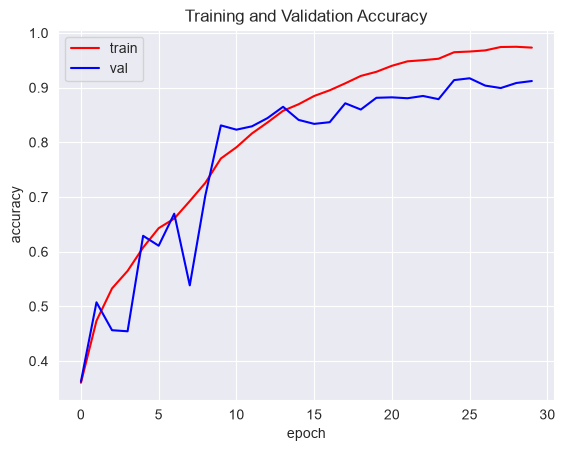

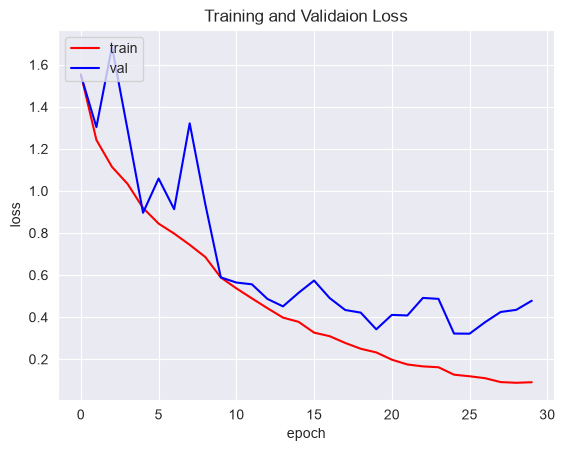

In [71]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(len(acc))

plt.plot(epochs, acc, "r")
plt.plot(epochs, val_acc, "b")
plt.title("Training and Validation Accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="upper left")
plt.show()

plt.plot(epochs, loss, "r")
plt.plot(epochs, val_loss, "b")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="upper left")
plt.title("Training and Validaion Loss")
plt.show()

In [72]:
def get_train_test_acc(train_gen, test_gen, model):
    # Reset generator
    train_gen.reset()
    test_gen.reset()

    # Evaluasi Training Set
    train_loss, train_acc = model.evaluate(train_generator, verbose=0)

    # Evaluasi Testing Set
    test_loss, test_acc = model.evaluate(test_generator, verbose=0)

    # Tampilkan hasil
    return train_acc, test_acc, train_loss, test_loss

In [77]:
akurasi_training, akurasi_testing, loss_training, loss_testing = get_train_test_acc(train_generator, test_generator, model_CNN)

In [85]:
print(f'Akurasi Training: {akurasi_training:.2%}')
print(f'Akurasi Testing: {akurasi_testing:.2%}')
print(f'Loss Training: {loss_training:.2%}')
print(f'Loss Testing: {loss_testing:.2%}')

Akurasi Training: 98.83%
Akurasi Testing: 93.35%
Loss Training: 4.29%
Loss Testing: 24.83%


In [74]:
def get_classification_report_cm(test_gen, model):
    # Reset generator agar urutan data sesuai label
    test_gen.reset()

    # Prediksi probabilitas untuk seluruh data test
    y_pred_prob = model.predict(test_gen, verbose=0)

    # Ambil kelas dengan probabilitas tertinggi (multi-class)
    y_pred = np.argmax(y_pred_prob, axis=1)

    # Label sebenarnya
    y_true = test_gen.classes

    # Nama-nama kelas (urut sesuai index)
    class_labels = list(test_gen.class_indices.keys())

    # Hitung confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels,
        cbar=True,
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix - Multi-Class")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Classification report (precision, recall, f1-score per kelas)
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

    # (Opsional) Normalized confusion matrix — berguna kalau jumlah data per kelas tidak seimbang
    cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels,
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Normalized Confusion Matrix")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # (Opsional) Akurasi per kelas dari confusion matrix
    print("\nAkurasi per kelas:")
    for i, label in enumerate(class_labels):
        class_acc = cm[i, i] / cm[i].sum()
        print(f"{label}: {class_acc*100:.2f}%")

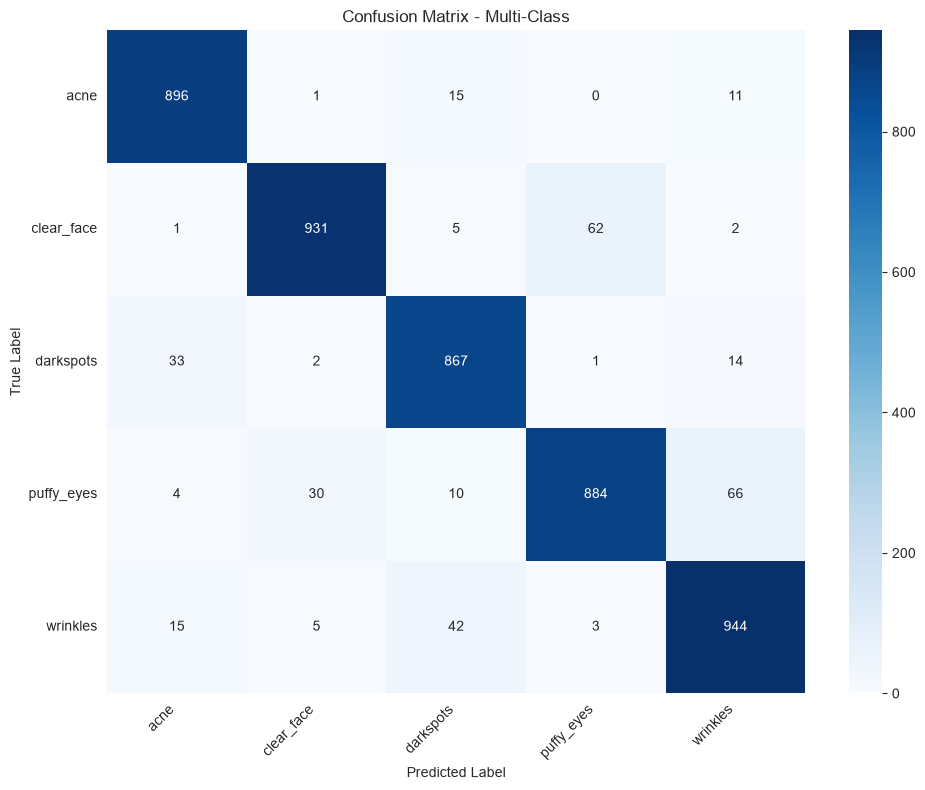

Classification Report:
              precision    recall  f1-score   support

        acne     0.9442    0.9707    0.9573       923
  clear_face     0.9608    0.9301    0.9452      1001
   darkspots     0.9233    0.9455    0.9343       917
  puffy_eyes     0.9305    0.8893    0.9095       994
    wrinkles     0.9103    0.9356    0.9228      1009

    accuracy                         0.9335      4844
   macro avg     0.9338    0.9342    0.9338      4844
weighted avg     0.9338    0.9335    0.9334      4844



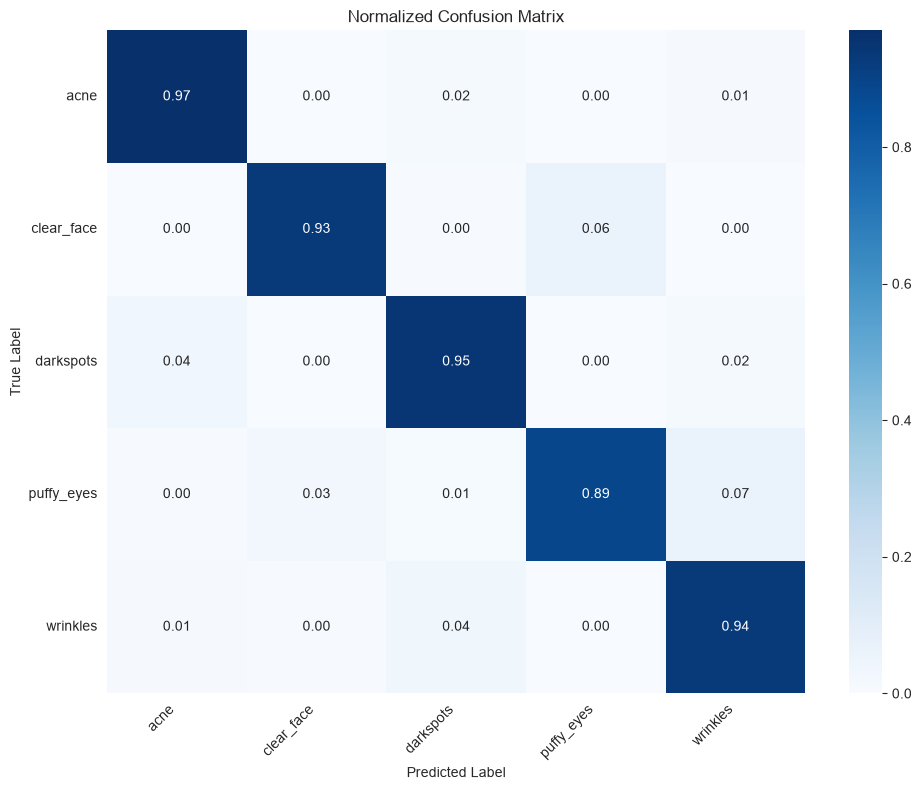


Akurasi per kelas:
acne: 97.07%
clear_face: 93.01%
darkspots: 94.55%
puffy_eyes: 88.93%
wrinkles: 93.56%


In [75]:
get_classification_report_cm(test_generator, model_CNN)

# 5.Simpan Model SavedModels

In [103]:
save_dir = './saved_model'

os.mkdir(save_dir)

tf.saved_model.save(model_CNN, save_dir)
print(f'model CNN disimpan di {save_dir}')

INFO:tensorflow:Assets written to: ./saved_model\assets


INFO:tensorflow:Assets written to: ./saved_model\assets


model CNN disimpan di ./saved_model


In [104]:
# Menyimpan model dalam format HDF5
model_CNN.save(os.path.join(save_dir, 'facial_skin_ageing_model_cnn.h5'))
print(f"model CNN disimpan di {save_dir}/facial_skin_ageing_model_cnn.h5")

model CNN disimpan di ./saved_model/facial_skin_ageing_model_cnn.h5


In [135]:
import json

class_names = list(test_generator.class_indices.keys())

with open(os.path.join(save_dir, 'class_indices.json'), 'w') as f:
    json.dump(class_names, f, indent=4)

# 6.Simpan/Convert Model to TensorFlow JS

In [ ]:
save_dir_tfjs = './tfjs_model'

os.mkdir(save_dir_tfjs)

In [125]:
import numpy as np
if not hasattr(np, "object"):
    np.object = object
if not hasattr(np, "bool"):
    np.bool = bool

In [148]:
import tensorflowjs as tfjs

tfjs.converters.convert_tf_saved_model(
    "./saved_model",  # path folder hasil export sebelumnya
    "./tfjs_model",  # folder output
)

print(f'model tfjs berhasil disimpan di ./tfjs_model/model.json')

Writing weight file ./tfjs_model\model.json...
model tfjs berhasil disimpan di ./tfjs_model/model.json


# 7.Simpan/Convert Model ke TensorFlow Lite (TFLITE)

In [149]:
save_dir_tflite = './tflite'

os.mkdir(save_dir_tflite)

# Konversi model yang disimpan dalam format SavedModel
converter = tf.lite.TFLiteConverter.from_saved_model(save_dir)
tflite_model = converter.convert()

with tf.io.gfile.GFile(os.path.join(save_dir_tflite, 'model.tflite'), 'wb') as f:
    f.write(tflite_model)

print(f'model SavedModel berhasil diconvert dan disimpan di ./tflite/model.tflite')

model SavedModel berhasil diconvert dan disimpan di ./tflite/model.tflite


In [150]:
# Konversi model yang disimpan dalam format keras
converter_keras = tf.lite.TFLiteConverter.from_keras_model(save_dir)
tflite_model_keras = converter.convert()

with tf.io.gfile.GFile(os.path.join(save_dir_tflite, 'facial_skin_ageing_model_cnn.tflite'), 'wb') as f:
    f.write(tflite_model_keras)

print(f"model keras berhasil diconvert dan disimpan di ./tflite/facial_skin_ageing_model_cnn.tflite")

model keras berhasil diconvert dan disimpan di ./tflite/facial_skin_ageing_model_cnn.tflite


In [151]:
class_indices = train_generator.class_indices
labels = sorted(class_indices.items(), key=lambda x: x[1])

with open(os.path.join(save_dir_tflite, "label.txt"), "w") as f:
    for class_name, idx in labels:
        f.write(f"{class_name}\n")

print("label.txt berhasil dibuat")
print("Isi label.txt:")
for class_name, idx in labels:
    print(f"{idx}: {class_name}")

print(f'class indice dari test_generator berhasil disimpan di ./tflite/label.txt')

label.txt berhasil dibuat
Isi label.txt:
0: acne
1: clear_face
2: darkspots
3: puffy_eyes
4: wrinkles
class indice dari test_generator berhasil disimpan di ./tflite/label.txt


**Inferensi (Demo)**

In [131]:
model = tf.keras.models.load_model("./saved_model/facial_skin_ageing_model_cnn.h5")

In [145]:
with open('./saved_model/class_indices.json', 'r') as f:
    class_name = json.load(f)

IMG_SIZE = (150, 150)  # sesuaikan dengan input size pada model yang sudah dibangun.

In [143]:
from tkinter import Tk, filedialog

def select_image():
    root = Tk()
    root.withdraw()
    root.attributes("-topmost", True)
    img_path = filedialog.askopenfilename(
        title="Pilih gambar untuk prediksi",
        filetypes=[("Image files", "*.jpg *.jpeg *.png")],
    )
    root.destroy()
    return img_path

In [144]:
def preprocess_image(img_path, target_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0
    return img_array, img

In [146]:
def predict_new_image(img_path):
    img_array, original_img = preprocess_image(img_path)

    predictions = model.predict(img_array, verbose=0)[0]
    predicted_idx = np.argmax(predictions)
    predicted_label = class_name[predicted_idx]
    confidence = predictions[predicted_idx] * 100

    print("=" * 40)
    print(f"Gambar        : {img_path}")
    print(f"Prediksi      : {predicted_label}")
    print(f"Confidence    : {confidence:.2f}%")
    print("=" * 40)

    print("\nPersentase confidence per kelas:")
    sorted_indices = np.argsort(predictions)[::-1]
    for idx in sorted_indices:
        print(f"  {class_name[idx]:<20}: {predictions[idx]*100:.2f}%")

    plt.figure(figsize=(5, 5))
    plt.imshow(original_img)
    plt.title(f"Prediksi: {predicted_label} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

    return predicted_label, confidence, predictions

Gambar        : D:/Machine Learning/Belajar_Fundamental_Deep_Learning/Face_Skin_Ageing_Image_Classification/nenek_insidius.jpg
Prediksi      : wrinkles
Confidence    : 97.85%

Persentase confidence per kelas:
  wrinkles            : 97.85%
  acne                : 2.01%
  puffy_eyes          : 0.08%
  darkspots           : 0.05%
  clear_face          : 0.00%


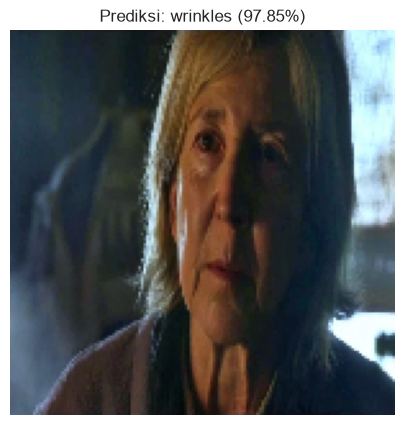

In [147]:
img_path = select_image()

if img_path:
    label, conf, all_scores = predict_new_image(img_path)
else:
    print("Tidak ada gambar yang dipilih.")